# Stage 6 — Hardware / Noise-Model Retuning

### Part of: *Quantum Circuit-Based Adaptation for Credit Risk Analysis*

**Previous:** ← `05_transpilation.ipynb`
**Next:** → `07_run_on_backend.ipynb`

---

Stage 5 produced a circuit that *fits* on a connectivity-limited device. It said nothing about whether that circuit *behaves* correctly once real imperfections are switched on. This notebook switches them on, shows that the Stage-4 angles no longer produce the right distribution, and then fixes the angles **in situ** in two ways, head to head:

- **6A — baseline (base paper):** a manual, brute-force, degree-by-degree grid sweep of one or two angles at a time.
- **6B — this project's novelty:** an automated, closed-loop calibration (Bayesian optimisation → Bayesian optimisation → SPSA) that minimises the Hellinger distance to the noiseless reference, using nothing but measured histograms.

## 1. What Is In-Situ Retuning? (General Overview)

On a real quantum processor a rotation $R_y(\theta)$ is not a mathematical object — it is a microwave pulse whose **amplitude** sets the angle and whose **phase** sets the axis (base paper, Sec. III: 60 ns DRAG pulses driven by FPGA electronics). If the pulse amplitude is 8 % too strong, every "$\theta$" the software asks for becomes $1.08\,\theta$ on the chip. Such *coherent* control errors are systematic, they differ from qubit to qubit, and they slowly drift as the chip is re-calibrated.

**In-situ retuning** means: keep the circuit structure fixed, but adjust the *commanded* angles while looking only at what the device actually outputs, until the output distribution matches what the algorithm needs. It is a calibration problem, solved by a classical optimiser wrapped around the quantum device — a second variational loop, this time with the hardware inside it.

## 2. Why We Do This Here

1. **The Stage-4 angles are only correct on a perfect machine.** They were trained on exact statevectors (Stage 4). The base paper found exactly this on its chip: the classically trained $\theta_1 = 111^\circ$ had to be moved to $237^\circ$ (pair D3–C4) and $224^\circ$ (pair D3–A6) on hardware (Sec. IV-A) — the "In-Situ Invalidation of Angles" gap from `00_overview.ipynb` §2.
2. **The base paper's fix does not scale.** It sweeps one angle at a time on a fixed grid (21° → 1°; 36° → 7.5°/14.5°), and for the full GCI circuit sweeps two more angles on a 2-D grid (Table 3). The number of circuit runs grows exponentially with the number of angles — the paper itself notes the optimisation "would need to be repeated for each variable in play" (Sec. V).
3. **This is where the project's novelty is tested.** Everything before this stage replicates the paper; Stage 6B replaces its manual sweep with an automated optimiser and measures whether it reaches a better distribution with fewer circuit executions.

## 3. Where This Fits in the Project Pipeline

This is **Stage 6 of 9**.

- **Input:** the trained angles $\theta^*$ (Stage 4), the asset parameters $\tilde\alpha, \tilde\beta$ (Stage 2), and the transpilation settings (Stage 5: native gates `rz, sx, x, cz`, SABRE on a linear coupling map).
- **Output:** three sets of *commanded* angles for the full GCI circuit — **uncalibrated** (Stage 4 as-is), **6A** (grid sweep) and **6B** (automated) — saved to `results/stage06_retuning.json`, which Stage 7 executes with thousands of shots.

## 4. Key Concepts

### 4.1 The noise-emulated device

The "chip" is a Qiskit `AerSimulator` wrapped in a small class (`src/device.py`). Three error sources are emulated — the same three the base paper identifies in Sec. V:

| Error source | How it is emulated | Value used | Paper reference |
|---|---|---|---|
| Depolarizing gate error | `depolarizing_error` on every `sx`, `x` (1-qubit) and `cz` (2-qubit); `rz` is virtual and error-free | 0.2 % (1q), 1.5 % (2q) | Sec. III, Table 1 |
| Readout bit-flips | per-physical-qubit `ReadoutError`, $P(1\to0)$ larger than $P(0\to1)$ (T1 decay during readout) | 2–7 % per qubit (≈5 % average) | Sec. IV-C: "readout error of about 5 %" |
| **Coherent control drift** | the chip applies $\theta_{\text{real}} = (1+\varepsilon_q)\,\theta + \delta_q$ on physical qubit $q$ | $\varepsilon_q$ up to ±14 %, $\delta_q$ up to ±15° | Sec. V: "undershoot or overshoot of control pulses used to implement $R_y$" |

The drift values live in `src/config.py` for transparency, but **no calibration method ever reads them** — they only see measured histograms, exactly like an experimentalist in front of a real chip.

### 4.2 The calibration objective

All methods minimise the same black-box function of the commanded angle vector $\mathbf{x}$:

$$
J(\mathbf{x}) = H\big(p_{\text{device}}(\mathbf{x}),\; p_{\text{ref}}\big), \qquad H(p,q) = \sqrt{1 - \textstyle\sum_i \sqrt{p_i q_i}}
$$

where $p_{\text{ref}}$ is the noiseless output of the Stage-4 circuit (the paper's "simulated transpiled circuit", Fig. 10a) and $p_{\text{device}}$ is estimated from 4 000 shots. Results are reported as **Hellinger fidelity** $F_H = (1-H^2)^2$, the paper's own metric.

### 4.3 Mitigation-aware calibration

The deployed pipeline also applies readout-error mitigation (Stage 7). If the angles were tuned on *raw* counts they would partly "absorb" the readout error, and readout mitigation would then correct it a second time. So every method here — 6A and 6B alike — tunes against **readout-mitigated** histograms. The comparison between 6A and 6B is therefore purely a comparison of *search strategies*.

### 4.4 Stage 6A — the base paper's grid sweep

| Circuit | Swept angles (others fixed) | Coarse grid | Fine grid |
|---|---|---|---|
| 2-qubit loader | $\theta_1$ | 90°…450°, step 21° | ±21°, step 1° |
| 3-qubit loader | $\theta_1, \theta_2$ | 90°…450°, step 36° (both) | ±36° step 7.5° / ±43.5° step 14.5° |
| full GCI circuit | asset angles $2\tilde\beta$, $2\tilde\alpha$ (loader angles from the loader sweep) | ±60° step 10° / ±15° step 3° | ±10° step 2° / ±3° step 0.5° |

These are the paper's own ranges and steps (Sec. IV-A, IV-B, Table 3). $\theta_0$ is kept fixed at its trained value, as in the paper.

### 4.5 Stage 6B — SPSA

Simultaneous Perturbation Stochastic Approximation estimates the *whole* gradient from just **two** measurements, whatever the number of angles $d$:

$$
\hat{g}_k = \frac{J(\mathbf{x}_k + c_k\boldsymbol{\Delta}_k) - J(\mathbf{x}_k - c_k\boldsymbol{\Delta}_k)}{2c_k}\,\boldsymbol{\Delta}_k,\qquad \Delta_{k,i}\in\{-1,+1\},
\qquad \mathbf{x}_{k+1} = \mathbf{x}_k - a_k\,\hat{g}_k
$$

with Spall's gain sequences $a_k = a/(k+1+A)^{0.602}$, $c_k = c/(k+1)^{0.101}$. It is the standard optimiser for noisy quantum objectives because shot noise simply averages out over iterations. (The parameter-shift rule from Stage 4 would need $2d$ runs per step, and its exactness is lost anyway once the gates are miscalibrated.)

### 4.6 Stage 6B — Bayesian optimisation

A **Gaussian process** (GP) is fitted to every $(\mathbf{x}, J)$ pair measured so far; it predicts both a mean $\mu(\mathbf{x})$ and an uncertainty $\sigma(\mathbf{x})$ everywhere. The next point measured is the one with the highest **Expected Improvement**

$$
\mathrm{EI}(\mathbf{x}) = (J^* - \mu)\,\Phi(z) + \sigma\,\varphi(z), \qquad z = \frac{J^* - \mu}{\sigma}
$$

which balances "go where the model predicts low $J$" against "go where the model is unsure". BO is extremely sample-efficient in low dimension — tens of circuit runs instead of hundreds. It is implemented from scratch in NumPy in `src/calibration.py` (RBF kernel, length-scale by maximum marginal likelihood).

### 4.7 Stage 6B — the full automated procedure

An automated mirror of the paper's own workflow, followed by a joint refinement:

1. **BO on the loader angles** $\theta_0 \dots \theta_{n-1}$, on the stand-alone loader circuit, on the same physical qubits (40 runs).
2. **BO on the two asset angles**, full GCI circuit, loader frozen (30 runs).
3. **Joint SPSA refinement** of all $n+2$ angles (60 iterations) — catches cross-talk a block-wise search cannot see.
4. **Verification:** the step-2 and step-3 candidates are both measured with 16 000 shots; the better one is kept.

For comparison, "one optimiser on all angles at once" (joint SPSA, joint BO) are run as **ablations**.

## 5. Implementation

### 5.1 Setup — building the noisy device

In [1]:
import os, sys, json
sys.path.insert(0, os.path.abspath("."))

import numpy as np
import matplotlib.pyplot as plt

from src import config as C
from src.stages import (make_device, mitigated, stage06_loader, stage06_gci, save_stage06)
from src.metrics import hellinger_fidelity
from src.pipeline_io import save_fig, nominal_parameters
from src.gci_model import target_gaussian_histogram

BLUE, RED, GREEN, GREY, ORANGE = "#1f4e8c", "#c0392b", "#27ae60", "#7f8c8d", "#e67e22"
np.set_printoptions(precision=4, suppress=True)

for n in C.REGISTER_SIZES:
    x_nom = nominal_parameters(n)
    print(f"{n}-qubit register  nominal commanded angles (deg): "
          f"theta = {np.round(np.rad2deg(x_nom[:n]), 2)}, "
          f"2*beta~ = {np.rad2deg(2 * x_nom[n]):.2f}, 2*alpha~ = {np.rad2deg(2 * x_nom[n + 1]):.2f}")

2-qubit register  nominal commanded angles (deg): theta = [ 90.   195.35], 2*beta~ = 80.85, 2*alpha~ = -13.86
3-qubit register  nominal commanded angles (deg): theta = [ 89.99  55.04 131.01], 2*beta~ = 80.85, 2*alpha~ = -5.94


In [2]:
devices = {n: make_device(n, "gci") for n in C.REGISTER_SIZES}
for n, (dev, x0, ref) in devices.items():
    s = dev.summary()
    print(f"=== {n}-qubit z-register GCI circuit on the mock device ===")
    print(f"  physical qubits used (logical -> physical): {s['logical_to_physical']}")
    print(f"  transpiled depth = {s['transpiled_depth']}, gates = {s['transpiled_gate_counts']}")
    print("  hidden control drift on those qubits (never shown to the optimisers):")
    for d in s["drift_per_logical_qubit"]:
        print(f"     logical q{d['logical_qubit']} -> physical Q{d['physical_qubit']}: "
              f"amplitude error {d['eps']:+.0%}, offset {d['delta_deg']:+.0f} deg")

=== 2-qubit z-register GCI circuit on the mock device ===
  physical qubits used (logical -> physical): [2, 1, 3]
  transpiled depth = 40, gates = {'rz': 24, 'sx': 20, 'cz': 8, 'measure': 3, 'barrier': 1}
  hidden control drift on those qubits (never shown to the optimisers):
     logical q0 -> physical Q2: amplitude error +14%, offset +10 deg
     logical q1 -> physical Q1: amplitude error -10%, offset -15 deg
     logical q2 -> physical Q3: amplitude error -11%, offset -12 deg
=== 3-qubit z-register GCI circuit on the mock device ===
  physical qubits used (logical -> physical): [3, 2, 4, 1]
  transpiled depth = 67, gates = {'rz': 36, 'sx': 33, 'cz': 14, 'measure': 4, 'barrier': 1}
  hidden control drift on those qubits (never shown to the optimisers):
     logical q0 -> physical Q3: amplitude error -11%, offset -12 deg
     logical q1 -> physical Q2: amplitude error +14%, offset +10 deg
     logical q2 -> physical Q4: amplitude error +10%, offset +14 deg
     logical q3 -> physical 

### 5.2 The problem, made visible

Run the Stage-4 circuit, with its trained angles, on the noisy device and compare with the noiseless reference. Readout mitigation alone (orange) is also shown: it removes the readout error but **cannot** remove the coherent drift — which is why retuning is needed at all.

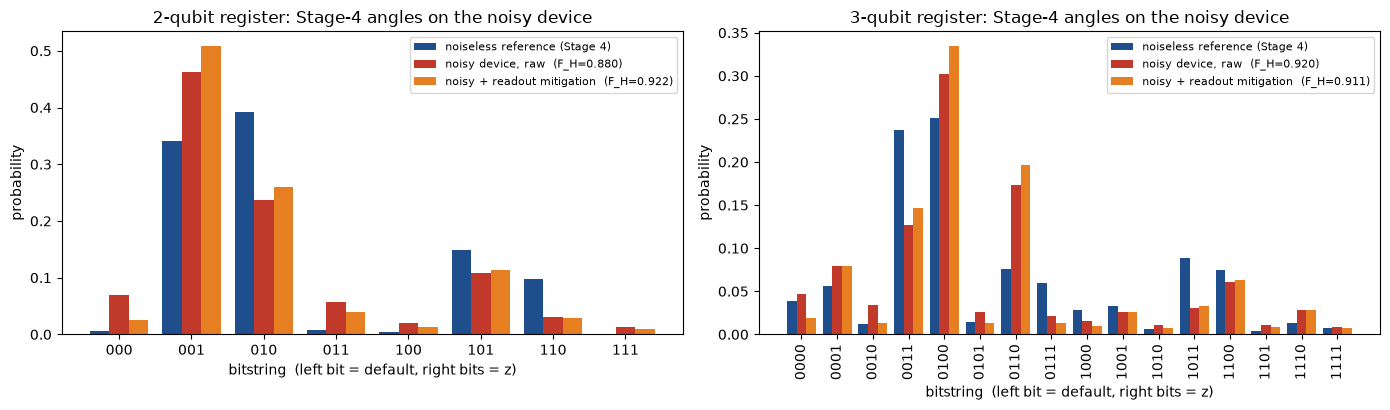

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
problem = {}
for ax, n in zip(axes, C.REGISTER_SIZES):
    dev, x0, ref = devices[n]
    A, M = mitigated(dev)
    raw = dev.run(x0, C.SHOTS_FINAL_CHECK, seed=11)
    rem = M.run(x0, C.SHOTS_FINAL_CHECK, seed=11)
    problem[n] = (hellinger_fidelity(raw, ref), hellinger_fidelity(rem, ref))
    k = np.arange(len(ref)); w = 0.27
    ax.bar(k - w, ref, w, color=BLUE, label="noiseless reference (Stage 4)")
    ax.bar(k, raw, w, color=RED, label=f"noisy device, raw  (F_H={problem[n][0]:.3f})")
    ax.bar(k + w, rem, w, color=ORANGE, label=f"noisy + readout mitigation  (F_H={problem[n][1]:.3f})")
    ax.set_xticks(k); ax.set_xticklabels([format(i, f"0{n+1}b") for i in k], rotation=90 if n == 3 else 0)
    ax.set_title(f"{n}-qubit register: Stage-4 angles on the noisy device")
    ax.set_xlabel("bitstring  (left bit = default, right bits = z)"); ax.set_ylabel("probability")
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig(fig, "stage06_problem_uncalibrated.png"); plt.show()

Two observations. The drift pushes the distribution visibly away from the reference, and readout mitigation on its own does not bring it back — it can even make things slightly *worse* (3-qubit case), because on this particular chip the drift and the readout bias happen to push some outcomes in opposite directions; removing only one of them un-hides the other. The coherent part of the error has to be fixed at the source: in the angles.

### 5.3 Part A — the Gaussian loader alone (paper Sec. IV-A / IV-B)

First, reproduce the paper's hardware sweep of $\theta_1$ with $\theta_0$ fixed (its Fig. 5): the probability of each basis state as a function of $\theta_1$, measured on the noisy device, against the noiseless theory. The periodic structure — concave, uniform at 90°/270°, inverted — is exactly what the paper observed.

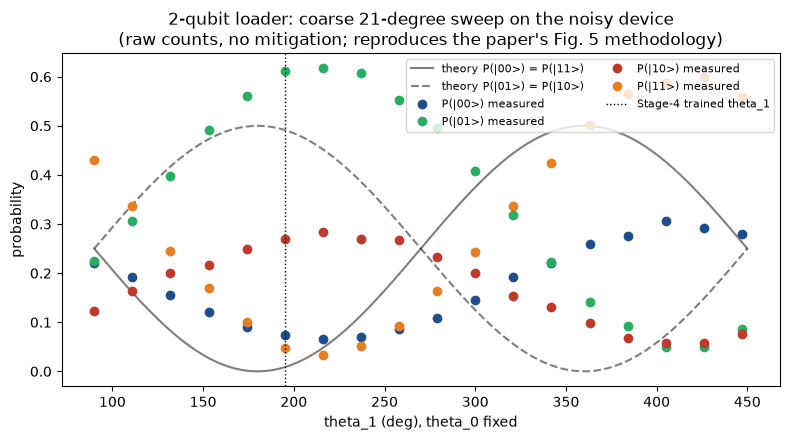

In [4]:
from src.device import NoisyDevice
ldev, lx0, lref = make_device(2, "loader")
thetas = np.deg2rad(np.arange(90, 451, 21))
xs = [np.array([lx0[0], t]) for t in thetas]
measured = np.array(ldev.run_many(xs, 4000, seed=5))
fine = np.deg2rad(np.linspace(90, 450, 300))
theory = np.array([ldev.ideal_probs(np.array([lx0[0], t])) for t in fine])

fig, ax = plt.subplots(figsize=(8, 4.5))
cols = [BLUE, GREEN, RED, ORANGE]
ax.plot(np.rad2deg(fine), theory[:, 0], color="k", lw=1.5, alpha=0.5, label="theory P(|00>) = P(|11>)")
ax.plot(np.rad2deg(fine), theory[:, 1], color="k", lw=1.5, ls="--", alpha=0.5, label="theory P(|01>) = P(|10>)")
for b in range(4):
    ax.plot(np.rad2deg(thetas), measured[:, b], "o", color=cols[b], label=f"P(|{b:02b}>) measured")
ax.axvline(np.rad2deg(lx0[1]) % 360 + (360 if np.rad2deg(lx0[1]) % 360 < 90 else 0), color="k", ls=":", lw=1,
           label="Stage-4 trained theta_1")
ax.set_xlabel("theta_1 (deg), theta_0 fixed"); ax.set_ylabel("probability")
ax.set_title("2-qubit loader: coarse 21-degree sweep on the noisy device\n(raw counts, no mitigation; reproduces the paper's Fig. 5 methodology)")
ax.legend(fontsize=8, ncol=2); plt.tight_layout()
save_fig(fig, "stage06_theta1_sweep_2q.png"); plt.show()

In theory (black lines) the pairs $|00\rangle,|11\rangle$ and $|01\rangle,|10\rangle$ coincide. On the noisy device they split apart: that asymmetry is the signature of the drift on $\theta_0$ (which this sweep cannot touch) plus readout bias — the same kind of asymmetry the paper attributes to SPAM errors in Sec. IV-A.

Now run all loader calibrations for both register sizes: **6A** (paper grid), **6B BO** (used as step 1 of the automated procedure), and an **SPSA** ablation.

In [5]:
loader = {}
for n in C.REGISTER_SIZES:
    loader[n] = stage06_loader(n, verbose=True)
    print()

[2q loader] uncalibrated: F_H raw = 0.9193, with readout mitigation = 0.9595


   grid_6A       : F_H = 0.9618   circuit evaluations =   61
   bo_6B         : F_H = 0.9997   circuit evaluations =   40
   spsa_ablation : F_H = 0.9999   circuit evaluations =  308



[3q loader] uncalibrated: F_H raw = 0.9266, with readout mitigation = 0.8972


   grid_6A       : F_H = 0.9645   circuit evaluations =  191
   bo_6B         : F_H = 0.9998   circuit evaluations =   40
   spsa_ablation : F_H = 0.9998   circuit evaluations =  308



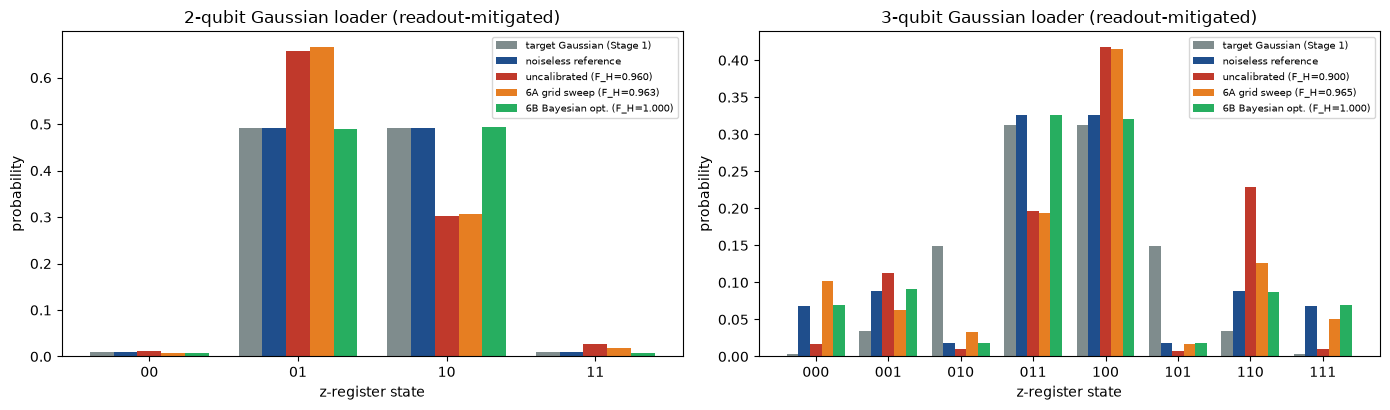

Note: the noiseless 3-qubit reference itself only reaches F_H = 0.783 against the ideal Gaussian --
that is the expressivity ceiling of the 3-parameter star ansatz found in Stage 4, not a noise effect.


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.2))
for ax, n in zip(axes, C.REGISTER_SIZES):
    summ, objs = loader[n]
    M, ref = objs["M"], objs["ref"]
    target = np.array(summ["target_gaussian"])
    series = [("target Gaussian (Stage 1)", target, GREY),
              ("noiseless reference", ref, BLUE),
              ("uncalibrated", M.run(objs["x0"], 20000, seed=3), RED),
              ("6A grid sweep", M.run(objs["grid"].x_best, 20000, seed=3), ORANGE),
              ("6B Bayesian opt.", M.run(objs["bo"].x_best, 20000, seed=3), GREEN)]
    k = np.arange(2 ** n); w = 0.16
    for i, (lab, p, c) in enumerate(series):
        f = "" if i < 2 else f" (F_H={hellinger_fidelity(p, ref):.3f})"
        ax.bar(k + (i - 2) * w, p, w, color=c, label=lab + f)
    ax.set_xticks(k); ax.set_xticklabels([format(i, f"0{n}b") for i in k])
    ax.set_title(f"{n}-qubit Gaussian loader (readout-mitigated)"); ax.set_xlabel("z-register state")
    ax.set_ylabel("probability"); ax.legend(fontsize=7.5)
plt.tight_layout(); save_fig(fig, "stage06_loader_distributions.png"); plt.show()

print("Note: the noiseless 3-qubit reference itself only reaches "
      f"F_H = {hellinger_fidelity(loader[3][1]['ref'], loader[3][0]['target_gaussian']):.3f} against the ideal Gaussian --")
print("that is the expressivity ceiling of the 3-parameter star ansatz found in Stage 4, not a noise effect.")

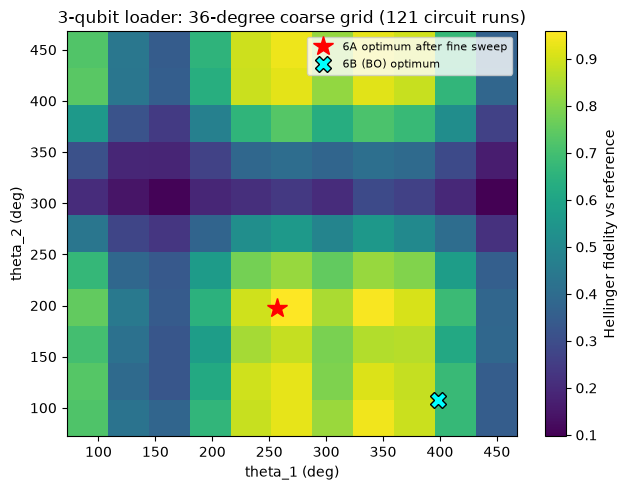

In [7]:
# The paper's 3-qubit coarse sweep as a landscape (like its Supplementary Fig. S12)
g3 = loader[3][1]["grid"]
land = g3.extra["landscape"]
ax1, ax2 = [np.rad2deg(a) for a in land["coarse_axes"]]
F = (1 - land["coarse_distance"] ** 2) ** 2
fig, ax = plt.subplots(figsize=(6.5, 5))
im = ax.imshow(F.reshape(len(ax1), len(ax2)).T, origin="lower", aspect="auto", cmap="viridis",
               extent=[ax1[0] - 18, ax1[-1] + 18, ax2[0] - 18, ax2[-1] + 18])
bx = np.rad2deg(g3.x_best)
ax.plot(bx[1], bx[2], "r*", ms=15, label="6A optimum after fine sweep")
bb = np.rad2deg(loader[3][1]["bo"].x_best) % 360
bb = np.where(bb < 90, bb + 360, bb)
ax.plot(bb[1], bb[2], "X", color="cyan", mec="k", ms=12, label="6B (BO) optimum")
plt.colorbar(im, label="Hellinger fidelity vs reference")
ax.set_xlabel("theta_1 (deg)"); ax.set_ylabel("theta_2 (deg)")
ax.set_title("3-qubit loader: 36-degree coarse grid (121 circuit runs)")
ax.legend(fontsize=8, loc="upper right"); plt.tight_layout()
save_fig(fig, "stage06_loader_landscape_3q.png"); plt.show()

A nice cross-check with the base paper: for the 2-qubit loader the 6A sweep moves $\theta_1$ from the trained 195° to about **234°** — the paper's own hardware sweeps landed at **237°** (pair D3–C4) and **224°** (pair D3–A6), Sec. IV-A. (Our drift values are not fitted to the paper; the agreement just shows the emulated miscalibration has a realistic size.)

Two more things stand out. First, the grid can only move $\theta_1$ (and $\theta_2$) — with $\theta_0$ frozen, the drift on the *first* qubit can never be corrected, so 6A plateaus. Second, BO tunes every angle at once and needs only 40 runs, fewer than even the 2-qubit grid (61 runs) and far fewer than the 3-qubit grid (191 runs).

### 5.4 Part B — the full GCI circuit (paper Sec. IV-C)

In [8]:
gci, params = {}, {}
for n in C.REGISTER_SIZES:
    summ, par, objs = stage06_gci(n, loader[n][1], verbose=True)
    gci[n], params[n] = (summ, objs), par
    print()

[2q GCI]    uncalibrated: F_H raw = 0.8801, with readout mitigation = 0.9225


   grid_6A             : F_H = 0.9389   circuit evaluations =  347
   auto_6B             : F_H = 0.9818   circuit evaluations =  204
   joint_spsa_ablation : F_H = 0.9820   circuit evaluations =  308
   joint_bo_ablation   : F_H = 0.9727   circuit evaluations =   70



[3q GCI]    uncalibrated: F_H raw = 0.9199, with readout mitigation = 0.9099


   grid_6A             : F_H = 0.9570   circuit evaluations =  477
   auto_6B             : F_H = 0.9943   circuit evaluations =  204
   joint_spsa_ablation : F_H = 0.9469   circuit evaluations =  308
   joint_bo_ablation   : F_H = 0.9637   circuit evaluations =   70



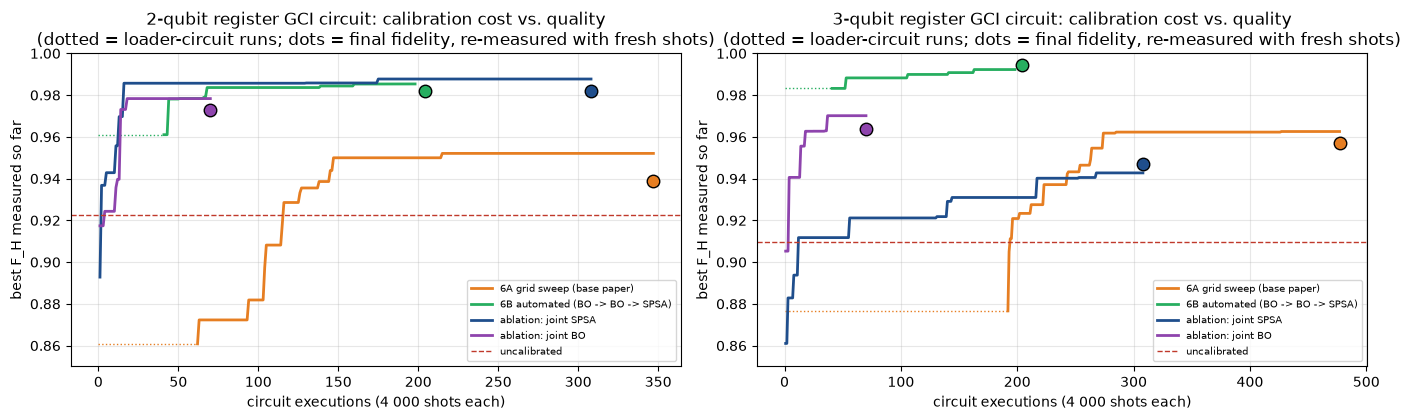

In [9]:
# Convergence: best objective found so far vs. number of circuit executions
labels = {"grid_6A": "6A grid sweep (base paper)", "auto_6B": "6B automated (BO -> BO -> SPSA)",
          "joint_spsa_ablation": "ablation: joint SPSA", "joint_bo_ablation": "ablation: joint BO"}
colors = {"grid_6A": ORANGE, "auto_6B": GREEN, "joint_spsa_ablation": BLUE, "joint_bo_ablation": "#8e44ad"}
fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
for ax, n in zip(axes, C.REGISTER_SIZES):
    summ, objs = gci[n]
    lobj = loader[n][1]
    # (offset, history-on-the-GCI-circuit): the loader-calibration runs of 6A / 6B are spent
    # on the stand-alone loader circuit, so they are shown as an offset, not as GCI values
    curves = {"grid_6A": (lobj["grid"].n_evals, objs["grid"].history),
              "auto_6B": (lobj["bo"].n_evals, objs["auto"].history[lobj["bo"].n_evals:]),
              "joint_spsa_ablation": (0, objs["spsa"].history),
              "joint_bo_ablation": (0, objs["bo"].history)}
    for key, (off, h) in curves.items():
        F_best = (1 - np.minimum.accumulate(np.asarray(h)) ** 2) ** 2
        x = off + np.arange(1, len(F_best) + 1)
        ax.plot(x, F_best, color=colors[key], lw=2, label=labels[key])
        if off:
            ax.plot([0, off], [F_best[0]] * 2, color=colors[key], lw=1, ls=":")
        ax.plot(summ["methods"][key]["n_evals"], summ["methods"][key]["fidelity"], "o",
                color=colors[key], ms=9, mec="k")
    ax.axhline(summ["uncalibrated"]["fidelity"], color=RED, ls="--", lw=1, label="uncalibrated")
    ax.set_xlabel("circuit executions (4 000 shots each)"); ax.set_ylabel("best F_H measured so far")
    ax.set_title(f"{n}-qubit register GCI circuit: calibration cost vs. quality\n"
                 "(dotted = loader-circuit runs; dots = final fidelity, re-measured with fresh shots)")
    ax.set_ylim(0.85, 1.0); ax.grid(alpha=0.3); ax.legend(fontsize=7.5, loc="lower right")
plt.tight_layout(); save_fig(fig, "stage06_convergence_gci.png"); plt.show()

The dotted stretches at the start of the orange and green curves are the loader-calibration runs (spent on the stand-alone loader circuit, so they have no GCI value yet). The curves show the best value *measured* during the search, which is slightly optimistic because of shot noise; the dots are the honest numbers — each final angle set re-measured with fresh shots. Note also the joint-SPSA ablation for the 3-qubit register: five angles at once from a poor start is hard for a pure local method, which is exactly why 6B first places the angles with BO and only then refines them with SPSA.

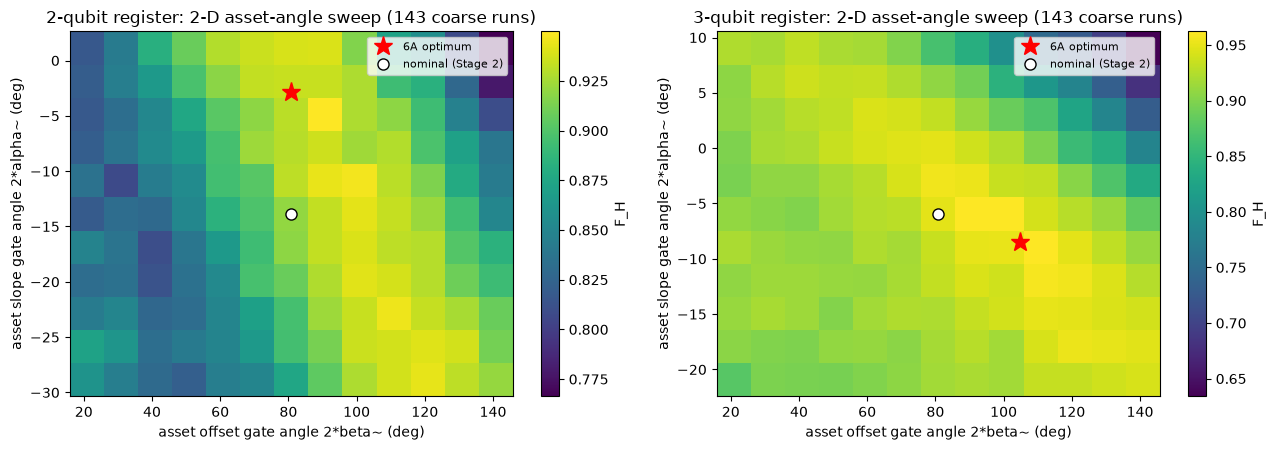

In [10]:
# The paper's Table 3 as a landscape: asset angles swept on the full GCI circuit
fig, axes = plt.subplots(1, 2, figsize=(13, 4.6))
for ax, n in zip(axes, C.REGISTER_SIZES):
    g = gci[n][1]["grid"]
    land = g.extra["landscape"]
    a1, a2 = [2 * np.rad2deg(a) for a in land["coarse_axes"]]      # gate angles 2*beta, 2*alpha
    F = ((1 - land["coarse_distance"] ** 2) ** 2).reshape(len(a1), len(a2))
    im = ax.imshow(F.T, origin="lower", aspect="auto", cmap="viridis",
                   extent=[a1[0] - 5, a1[-1] + 5, a2[0] - 1.5, a2[-1] + 1.5])
    xb = 2 * np.rad2deg(g.x_best)
    ax.plot(xb[n], xb[n + 1], "r*", ms=14, label="6A optimum")
    x0 = 2 * np.rad2deg(gci[n][1]["x0"])
    ax.plot(x0[n], x0[n + 1], "wo", ms=8, mec="k", label="nominal (Stage 2)")
    plt.colorbar(im, ax=ax, label="F_H")
    ax.set_xlabel("asset offset gate angle 2*beta~ (deg)"); ax.set_ylabel("asset slope gate angle 2*alpha~ (deg)")
    ax.set_title(f"{n}-qubit register: 2-D asset-angle sweep ({g.extra['n_coarse']} coarse runs)")
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig(fig, "stage06_asset_landscape.png"); plt.show()

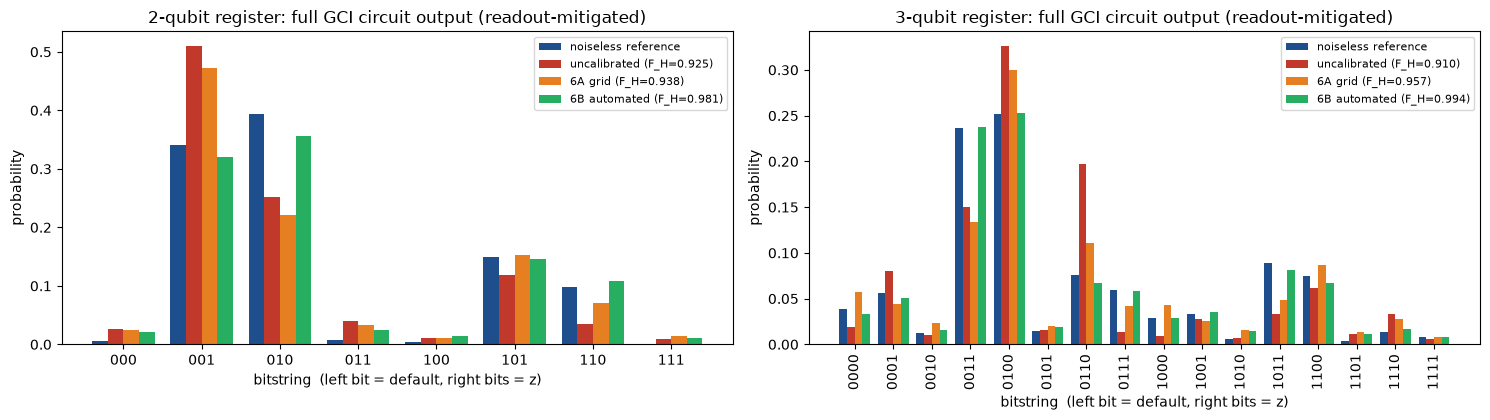

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 4.3))
for ax, n in zip(axes, C.REGISTER_SIZES):
    summ, objs = gci[n]
    M, ref = objs["M"], objs["ref"]
    series = [("noiseless reference", ref, BLUE),
              ("uncalibrated", M.run(objs["x0"], 20000, seed=21), RED),
              ("6A grid", M.run(objs["grid"].x_best, 20000, seed=21), ORANGE),
              ("6B automated", M.run(objs["auto"].x_best, 20000, seed=21), GREEN)]
    k = np.arange(len(ref)); w = 0.2
    for i, (lab, p, c) in enumerate(series):
        f = "" if i == 0 else f" (F_H={hellinger_fidelity(p, ref):.3f})"
        ax.bar(k + (i - 1.5) * w, p, w, color=c, label=lab + f)
    ax.set_xticks(k); ax.set_xticklabels([format(i, f"0{n+1}b") for i in k], rotation=90 if n == 3 else 0)
    ax.set_title(f"{n}-qubit register: full GCI circuit output (readout-mitigated)")
    ax.set_xlabel("bitstring  (left bit = default, right bits = z)"); ax.set_ylabel("probability")
    ax.legend(fontsize=8)
plt.tight_layout(); save_fig(fig, "stage06_gci_distributions.png"); plt.show()

### 5.5 Cost vs. quality — the head-to-head result

 register | method                           | circuit runs |      shots |     F_H
----------------------------------------------------------------------------------
      2q  | uncalibrated (Stage 4)           |            0 |          0 |  0.9225
      2q  | 6A grid sweep (base paper)       |          347 |  1,388,000 |  0.9389
      2q  | 6B automated (this project)      |          204 |    816,000 |  0.9818
      2q  | ablation: joint SPSA             |          308 |  1,232,000 |  0.9820
      2q  | ablation: joint BO               |           70 |    280,000 |  0.9727
      3q  | uncalibrated (Stage 4)           |            0 |          0 |  0.9099
      3q  | 6A grid sweep (base paper)       |          477 |  1,908,000 |  0.9570
      3q  | 6B automated (this project)      |          204 |    816,000 |  0.9943
      3q  | ablation: joint SPSA             |          308 |  1,232,000 |  0.9469
      3q  | ablation: joint BO               |           70 |    280,000 |  0.9637


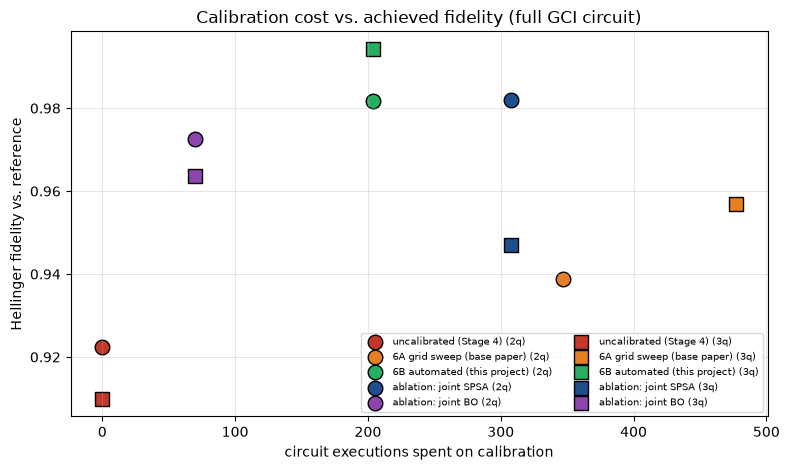

In [12]:
rows = []
for n in C.REGISTER_SIZES:
    summ = gci[n][0]
    rows.append((n, "uncalibrated (Stage 4)", 0, summ["uncalibrated"]["fidelity"]))
    for key, lab in [("grid_6A", "6A grid sweep (base paper)"), ("auto_6B", "6B automated (this project)"),
                     ("joint_spsa_ablation", "ablation: joint SPSA"), ("joint_bo_ablation", "ablation: joint BO")]:
        m = summ["methods"][key]
        rows.append((n, lab, m["n_evals"], m["fidelity"]))

print(f"{'register':>9} | {'method':32s} | {'circuit runs':>12} | {'shots':>10} | {'F_H':>7}")
print("-" * 82)
for n, lab, ev, f in rows:
    print(f"{n:>7}q  | {lab:32s} | {ev:>12d} | {ev * C.SHOTS_CALIBRATION:>10,d} | {f:7.4f}")

fig, ax = plt.subplots(figsize=(8, 4.8))
mk = {2: "o", 3: "s"}
col = {"uncalibrated (Stage 4)": RED, "6A grid sweep (base paper)": ORANGE, "6B automated (this project)": GREEN,
       "ablation: joint SPSA": BLUE, "ablation: joint BO": "#8e44ad"}
for n, lab, ev, f in rows:
    ax.scatter(ev, f, marker=mk[n], s=110, color=col[lab], edgecolor="k",
               label=f"{lab} ({n}q)")
ax.set_xlabel("circuit executions spent on calibration"); ax.set_ylabel("Hellinger fidelity vs. reference")
ax.set_title("Calibration cost vs. achieved fidelity (full GCI circuit)")
ax.grid(alpha=0.3); ax.legend(fontsize=7, ncol=2, loc="lower right"); plt.tight_layout()
save_fig(fig, "stage06_cost_vs_quality.png"); plt.show()

### 5.6 Saving the calibrated angles for Stage 7

In [13]:
results = {n: {"loader": loader[n][0], "gci": gci[n][0], "calibrated_parameters": params[n]}
           for n in C.REGISTER_SIZES}
path = save_stage06(results)
print(f"Saved -> {path}\n")
for n in C.REGISTER_SIZES:
    print(f"{n}-qubit register, commanded angles (deg)  [theta_0..theta_{n-1}, beta~, alpha~]:")
    for k, v in params[n].items():
        print(f"   {k:13s}: {np.round(np.rad2deg(v), 2)}")

Saved -> /home/muthuraam/quantum-credit-risk-vqc/results/stage06_retuning.json

2-qubit register, commanded angles (deg)  [theta_0..theta_1, beta~, alpha~]:
   uncalibrated : [ 90.   195.35  40.42  -6.93]
   grid_6A      : [ 90.   234.    40.42  -1.43]
   auto_6B      : [ 70.4  224.51  50.85  -6.82]
3-qubit register, commanded angles (deg)  [theta_0..theta_2, beta~, alpha~]:
   uncalibrated : [ 89.99  55.04 131.01  40.42  -2.97]
   grid_6A      : [ 89.99 256.5  198.    52.42  -4.22]
   auto_6B      : [115.01  34.37 109.92  55.32  -5.28]


## 6. What This Stage Produces

1. **A noise-emulated device** (`src/device.py`, `src/noise_model.py`) with the three error sources the base paper names: depolarizing gates, readout bit-flips and coherent per-qubit control drift.
2. **A reproduction of the paper's in-situ retuning (6A)** — its own sweep ranges and steps, its own workflow (loader first, then the two asset angles), including the $\theta_1$ sweep of its Fig. 5 and the asset-angle landscape of its Table 3.
3. **The project's novelty (6B)** — an automated closed-loop calibration (BO → BO → SPSA, mitigation-aware) that reaches a clearly higher Hellinger fidelity with fewer than half the circuit executions of the grid sweep, plus ablations showing why the hierarchical design matters.
4. **`results/stage06_retuning.json`** — the uncalibrated, 6A and 6B commanded angles for both register sizes, with every method's cost, history and fidelity.

## 7. What's Next

**Stage 7 — Execution (`07_run_on_backend.ipynb`):** the three angle sets are executed on the noise-emulated backend with 20 000 shots, repeated 20 times for error bars, and two standard error-mitigation techniques — readout-error mitigation and zero-noise extrapolation — are benchmarked on top of them.

---
*Next: → `07_run_on_backend.ipynb`*